In [44]:
#  libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [45]:
%matplotlib inline
sns.set_theme(style="whitegrid")

In [46]:
#Dataset
df_house = pd.read_csv('4) house Prediction Data Set.csv', sep='\s+', header = None)

# In this dataset, column index 5 represents room size/area, and 13 represents price
df_house = df_house.rename(columns={5: 'Area', 13: 'Price'})

print("--- Data Info ---")
df_house.info()
print("\n--- Missing Values ---")
print(df_house.isnull().sum())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       506 non-null    float64
 1   1       506 non-null    float64
 2   2       506 non-null    float64
 3   3       506 non-null    int64  
 4   4       506 non-null    float64
 5   Area    506 non-null    float64
 6   6       506 non-null    float64
 7   7       506 non-null    float64
 8   8       506 non-null    int64  
 9   9       506 non-null    float64
 10  10      506 non-null    float64
 11  11      506 non-null    float64
 12  12      506 non-null    float64
 13  Price   506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB

--- Missing Values ---
0        0
1        0
2        0
3        0
4        0
Area     0
6        0
7        0
8        0
9        0
10       0
11       0
12       0
Price    0
dtype: int64


In [47]:
# Drop missing values 
df_house = df_house.dropna()

print("\n--- Predicting 'Price' based on 'Area' ---")


--- Predicting 'Price' based on 'Area' ---


In [48]:
# 2. Select variables for Simple Linear Regression

X_reg = df_house[['Area']]
y_reg = df_house['Price']

In [49]:
# Split for test and train
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [50]:
#linear regression model using scikit-learn
model = LinearRegression()
model.fit(X_train, y_train)
    
# Make predictions using the test set
y_pred = model.predict(X_test)

# Interpret coefficients and evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Coefficient (Slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared: {r2:.4f}")


--- Model Evaluation ---
Coefficient (Slope): 9.3483
Intercept: -36.2463
Mean Squared Error (MSE): 46.14
R-squared: 0.3708


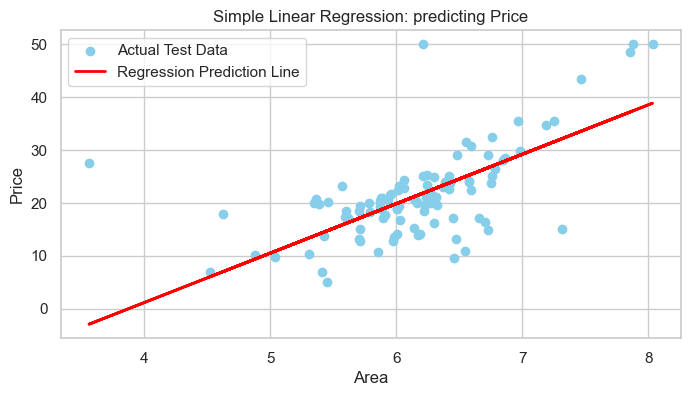

In [51]:
# 6. Visualize the regression results
plt.figure(figsize=(8, 4))
plt.scatter(X_test, y_test, color='skyblue', label='Actual Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Prediction Line')
plt.title(f'Simple Linear Regression: predicting {y_col}')
plt.xlabel(X_col)
plt.ylabel(y_col)
plt.legend()
plt.show()